In [ ]:
from itertools import count
import numpy as np

def sin(x, *, atol=1e-8, rtol=1e-8):
    # Check that tolerances are non-negative
    if atol < 0 or rtol < 0:
        raise ValueError("Invalid tolerance")
    # Reduce x into the range [-π, π] to improve numerical stability.
    x = np.mod(float(x) + np.pi, 2 * np.pi) - np.pi
    # Initialize the sum (y) of the Taylor series
    y = 0.
    # First term in the Taylor expansion of sin(x) is x
    t = x
    # Loop over terms in the Taylor series:
    # sin(x) = x - x^3/3! + x^5/5! - ...
    # count(start=1) gives i = 1, 2, 3, ...
    for i in count(start=1):
        # Add current term to running total
        y += t
        # Stop when the term is small relative to the result.
        if np.abs(t) <= np.maximum(atol, rtol * np.abs(y)):
            return y
        # Compute next term efficiently using recurrence relation.
        # Instead of computing factorials each time, we update:
        # t_next = -t * x^2 / ((2i)(2i+1))
        # This comes from ratio of consecutive Taylor terms.
        t *= -x ** 2 / ((2 * i) * (2 * i + 1))


def cos(x, *, atol=1e-8, rtol=1e-8):
    # Use identity: cos(x) = sin(x + π/2)
    # This avoids duplicating the Taylor series logic
    return sin(x + np.pi / 2, atol=atol, rtol=rtol)


In [4]:
import numpy as np

# derivative approximation from the question
def numerical_derivative(f, x, h):
    return (1/h) * (
        0.5 * f(x - h)
        - np.sqrt(2) * f(x - h/np.sqrt(2))
        + np.sqrt(2) * f(x + h/np.sqrt(2))
        - 0.5 * f(x + h)
    )
# test at a fixed point
x = 1.0
hs = [10**(-k) for k in range(1, 11)]
errors = []
for h in hs:
    approx = numerical_derivative(sin, x, h)
    exact = cos(x)
    error = abs(approx - exact)
    errors.append(error)
for h, e in zip(hs, errors):
    print(f"h={h:.1e}, error={e:.3e}")

h=1.0e-01, error=2.252e-07
h=1.0e-02, error=3.222e-12
h=1.0e-03, error=1.979e-11
h=1.0e-04, error=1.896e-11
h=1.0e-05, error=6.892e-11
h=1.0e-06, error=1.864e-10
h=1.0e-07, error=1.852e-09
h=1.0e-08, error=1.962e-08
h=1.0e-09, error=9.407e-07
h=1.0e-10, error=6.720e-06


The results of this clearly shows that as h decreases from 10^-1 to 10^-2 but, the error remains very small and constant between h = 10^-2 and 10^-5, but beyond 10^-6, this starts to rapidlty to greater error at 10^-10 than at 10^-1. the reason for this error at larger h is due to truncation error in the taylor series, whereas for small h this tends to 0, but there is still error in the derivitive approximation due to rounding off error in the arithmatic.

In [6]:
import numpy as np

# Define the function f(x)
def f(x):
    return 2*x + 0.9*np.sin(x)**2 - np.tanh(x)

# Residual F(x) = f(x) - y
def F(x, y):
    return f(x) - y

# Derivative of f(x) (needed for Newton)
def df(x):
    return 2 + 1.8*np.sin(x)*np.cos(x) - (1 / np.cosh(x))**2

# Fixed-point iteration
def fixed_point(x0, y, alpha, tol=1e-8, max_iter=100):
    x = x0
    for i in range(max_iter):
        x_new = x - (1/alpha) * F(x, y)
        if abs(x_new - x) < tol:
            return x_new, i+1
        x = x_new
    return x, max_iter

# Newton's method
def newton(x0, y, tol=1e-8, max_iter=100):
    x = x0
    for i in range(max_iter):
        x_new = x - F(x, y) / df(x)
        if abs(x_new - x) < tol:
            return x_new, i+1
        x = x_new
    return x, max_iter

# Test example
y = 1.0
x0 = 0.5
# Try different alpha values
alphas = [1, 2, 3, 4, 5]
for alpha in alphas:
    root, iters = fixed_point(x0, y, alpha)
    print(f"Fixed-point (alpha={alpha}): root={root:.6f}, iterations={iters}")
root, iters = newton(x0, y)
print(f"Newton: root={root:.6f}, iterations={iters}")

Fixed-point (alpha=1): root=0.156833, iterations=100
Fixed-point (alpha=2): root=0.623378, iterations=8
Fixed-point (alpha=3): root=0.623378, iterations=14
Fixed-point (alpha=4): root=0.623378, iterations=22
Fixed-point (alpha=5): root=0.623378, iterations=29
Newton: root=0.623378, iterations=4


Newton’s method usually shows better results. It converges quickly for a wide range of starting estimates in just a few iterations. This is due to its quadratic convergence, when the guess is close to the root the error reduces roughly as the square of the previous error which makes Newton’s method very efficient. However, it has some limitations because it relies on the derivative. If F′(x) is small or behaves poorly, the method might diverge or take big steps. Also, a bad initial guess can lead to finding the wrong root or not converging at all.

On the other hand, fixed-point iteration behaves quite differently based on the choice of the parameter α. For the right values of α, the method converges, but it does so only linearly, which is much slower than Newton’s method. If α is too small, the iteration can diverge because of large jumps. If α is too large, it converges steadily but very slowly. This shows that for convergence, the size of the iteration derivative needs to be less than one. Picking the best α depends on the problem whereas the newton method doesn't need this step. Regarding robustness, the fixed-point method can be more stable if α is chosen carefully, but this reduces efficiency. Newton’s method, while not as robust overall, is much more efficient when it works well.

In summary, Newton’s method is better when you have a good initial guess and the derivative behaves nicely, while fixed-point iteration can be a safer choice when stability is more important, even though it converges more slowly.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define F(U)
def F(U):
    x, y, u, v = U
    r = np.sqrt(x**2 + y**2)
    return np.array([
        u,
        v,
        -x / r**3,
        -y / r**3
    ])

# Energy function
def energy(U):
    x, y, u, v = U
    r = np.sqrt(x**2 + y**2)
    return 0.5 * (u**2 + v**2) - 1/r

# Forward Euler
def forward_euler(U0, h, N):
    U = np.zeros((N+1, 4))
    U[0] = U0
    for n in range(N):
        U[n+1] = U[n] + h * F(U[n])

    return U

# Semi-implicit Euler
def semi_implicit(U0, h, N):
    U = np.zeros((N+1, 4))
    U[0] = U0

    for n in range(N):
        x, y, u, v = U[n]
        r = np.sqrt(x**2 + y**2)
        u_new = u - h * x / r**3
        v_new = v - h * y / r**3
        x_new = x + h * u_new
        y_new = y + h * v_new

        U[n+1] = [x_new, y_new, u_new, v_new]

    return U

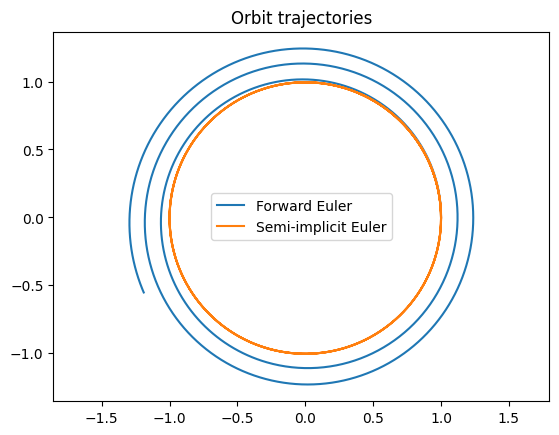

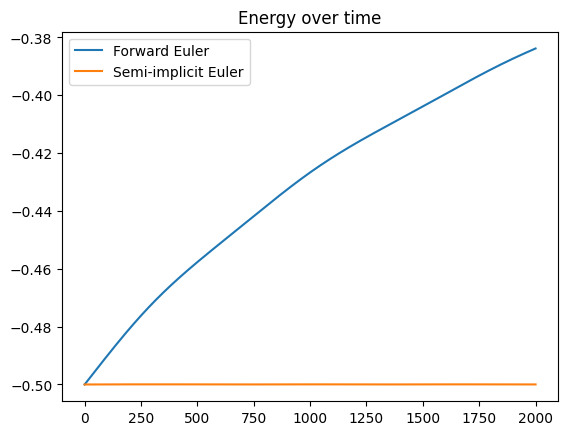

In [9]:
# Initial conditions (circular orbit approx)
U0 = np.array([1.0, 0.0, 0.0, 1.0])

h = 0.01
N = 2000

U_fe = forward_euler(U0, h, N)
U_si = semi_implicit(U0, h, N)

# Extract positions
x_fe, y_fe = U_fe[:,0], U_fe[:,1]
x_si, y_si = U_si[:,0], U_si[:,1]

# Plot trajectories
plt.figure()
plt.plot(x_fe, y_fe, label="Forward Euler")
plt.plot(x_si, y_si, label="Semi-implicit Euler")
plt.legend()
plt.axis('equal')
plt.title("Orbit trajectories")
plt.show()

# Energy comparison
E_fe = [energy(U) for U in U_fe]
E_si = [energy(U) for U in U_si]

plt.figure()
plt.plot(E_fe, label="Forward Euler")
plt.plot(E_si, label="Semi-implicit Euler")
plt.legend()
plt.title("Energy over time")
plt.show()

The plots shows a clear difference between the two methods in this test case. With forward Euler, the orbit slowly drifts outward instead of staying close to a circle. The energy plot also shows a steady increase from about −0.50 to around −0.38, which means the method is adding energy over time. That is a pretty strong sign that forward Euler is not a very good choice for this problem if you want a stable result. Since the system should not be gaining energy, this artificial energy increase is another reason the method performs badly

The semi-implicit Euler method does much better. Its orbit stays close to the original path and does not spiral away like the forward Euler one. On the energy plot, the line stays almost flat at about −0.50, so the energy is being kept much more under control. That makes the solution look much more realistic over a long run of steps.

Overall, the data suggests that semi-implicit Euler is the better method here. Both methods are simple, but forward Euler loses accuracy quite quickly, while the semi-implicit method stays stable and gives a much better approximation of the motion. These plots clearly show that semi-implicit Euler is more reliable for this type of numerical problem.